# Define constants

In [ ]:
import librosa
from os import path

SOURCE_PATH = path.normpath("../../validations/")

# Least audio duration
AUDIO_SAMPLE_RATE = 44_100 # Hz

# How many frames to skip in each samples
CQT_HOP_LENGTH = 512

# Bin numbers based on octaves for input
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36

# Starts from note
CQT_FMIN = librosa.note_to_hz('C1')

# Onset detection parameters
PEAK_PICKING_MCFEE = {
  "delta": 0.07,
  "pre_max": 30,
  "post_max": 1, # 0, must be positive in librosa
  "pre_avg": 100,
  "post_avg": 100,
  "wait": 30,
}

PEAK_PICKING_BOCK = {
  # "delta": default,
  "pre_max": 30,
  "post_max": 30,
  "pre_avg": 100,
  "post_avg": 70,
  "wait": 30,
}

# Show annotation plots

In [38]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np


def plot_feature_true_and_detected_onsets(
    sample_cqt,
    true_annotations,
    detected_onset_times=None,
    *,
    dataset_name="",
    sample_label=None,
    ax=None,
    title=None,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

    image = librosa.display.specshow(
        sample_cqt,
        x_axis='time',
        y_axis='cqt_note',
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        fmin=CQT_FMIN,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
        ax=ax,
    )

    y_bottom = ax.get_ylim()[0]
    for annotation in true_annotations:
        onset_time = annotation["start"]
        chord_name = annotation["chord"]
        ax.axvline(onset_time, color="cyan", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(
            onset_time,
            y_bottom,
            chord_name,
            va="bottom",
            ha="left",
            fontsize=8,
            color="cyan",
            bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=1),
        )

    if detected_onset_times is not None:
        for onset_time in np.atleast_1d(detected_onset_times):
            ax.axvline(onset_time, color="magenta", linestyle="-", linewidth=1, alpha=0.8)

    ax.text(
        0.01,
        0.98,
        dataset_name,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        color="cyan",
        bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=2),
    )

    if title is None:
        title_parts = []
        if dataset_name:
            title_parts.append(dataset_name)
        if sample_label is not None:
            title_parts.append(f"sample label: {sample_label}")
        title_parts.append(f"frames: {sample_cqt.shape[1]}")
        title = " | ".join(title_parts)

    ax.set_title(title)
    return image, ax

# Onset detection

## Define functions

In [39]:
def target_npz_path(dataset_name):
    return path.join(SOURCE_PATH, f"{dataset_name}.npz")

def detect_onsets_from_cqt(sample_cqt, parameters):
    onset_envelope = librosa.onset.onset_strength(
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        S=sample_cqt,
    )

    onset_frames = librosa.onset.onset_detect(
        onset_envelope=onset_envelope,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        backtrack=False,
        **parameters,
    )

    onset_times = librosa.frames_to_time(
        onset_frames,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
    )

    return onset_frames, onset_times, onset_envelope

def detect_onsets_for_dataset(dataset_name, parameters):
    npz_path = target_npz_path(dataset_name)
    data = np.load(npz_path, allow_pickle=True)
    features = data["features"]
    labels = data["labels"]
    annotations = data["annotations"]

    detections = []
    for sample_index, sample_cqt in enumerate(features):
        onset_frames, onset_times, onset_envelope = detect_onsets_from_cqt(sample_cqt, parameters)
        detections.append({
            "sample_index": sample_index,
            "label": labels[sample_index],
            "annotation": annotations[sample_index],
            "onset_frames": onset_frames,
            "onset_times": onset_times,
            "onset_envelope": onset_envelope,
        })

    return {
        "dataset_name": dataset_name,
        "features": features,
        "labels": labels,
        "annotations": annotations,
        "detections": detections,
    }

def detect_onsets_for_all_datasets(dataset_names, parameters):
    return {
        dataset_name: detect_onsets_for_dataset(dataset_name, parameters)
        for dataset_name in dataset_names
    }

validation_datasets = [
    # "major_only",
    "sustain_delay",
    "no_sustain_no_delay",
    "sustain_no_delay",
]

## McFee et al

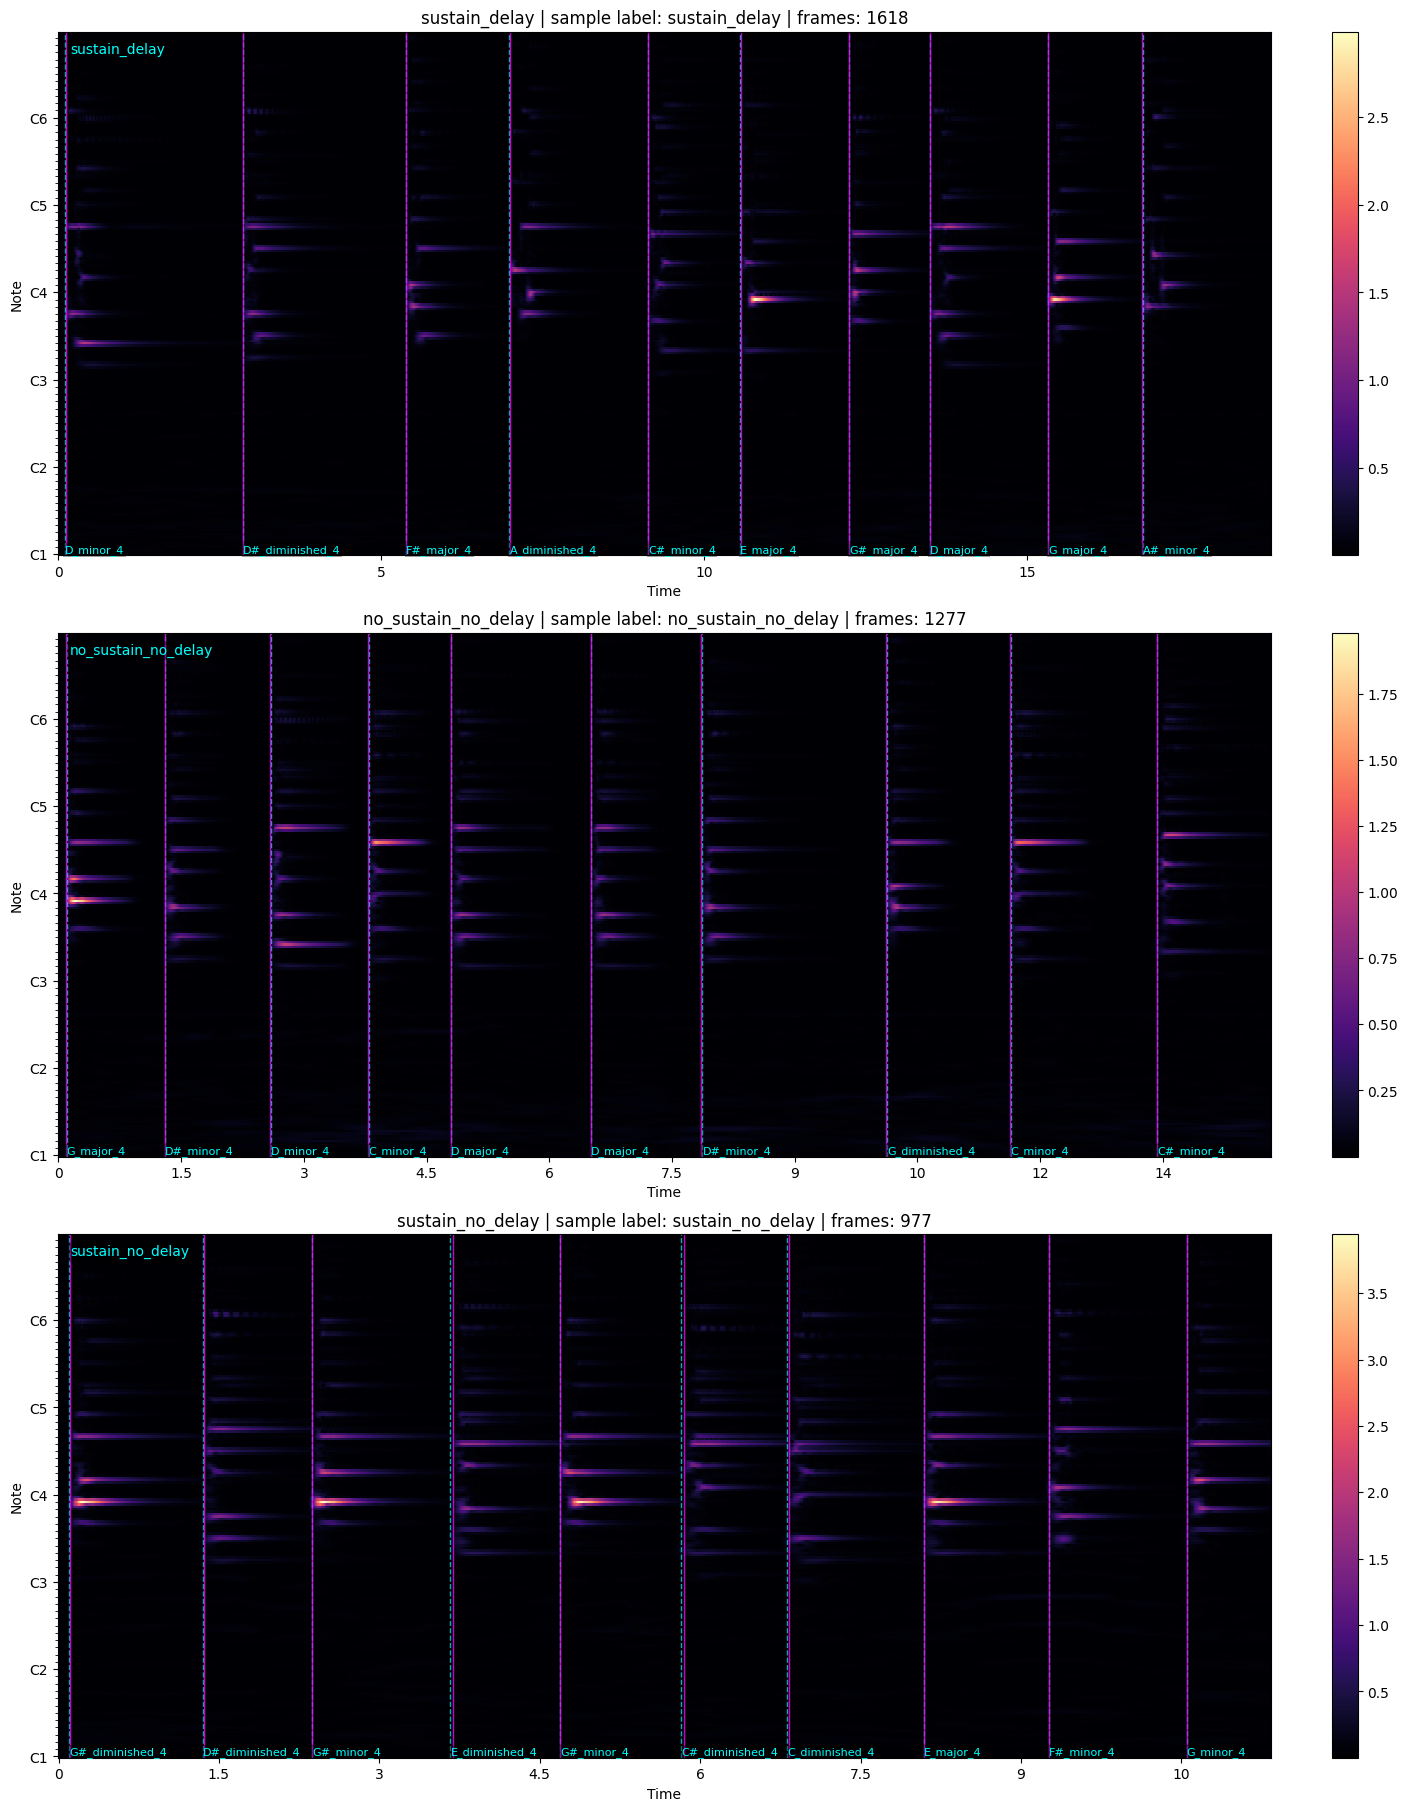

In [ ]:
mcfee_detections = detect_onsets_for_all_datasets(validation_datasets, PEAK_PICKING_MCFEE)

fig, axes = plt.subplots(len(validation_datasets), 1, figsize=(14, 18), constrained_layout=True)

for axis, dataset_name in zip(axes, validation_datasets):
    dataset_result = mcfee_detections[dataset_name]
    sample_cqt = dataset_result["features"][0]
    annotations = dataset_result["annotations"][0]
    detected_onset_times = dataset_result["detections"][0]["onset_times"]

    image, _ = plot_feature_true_and_detected_onsets(
        sample_cqt,
        annotations,
        detected_onset_times=detected_onset_times,
        dataset_name=dataset_name,
        sample_label=dataset_result["labels"][0],
        ax=axis,
    )
    fig.colorbar(image, ax=axis)

plt.show()

## Bock & Widmer

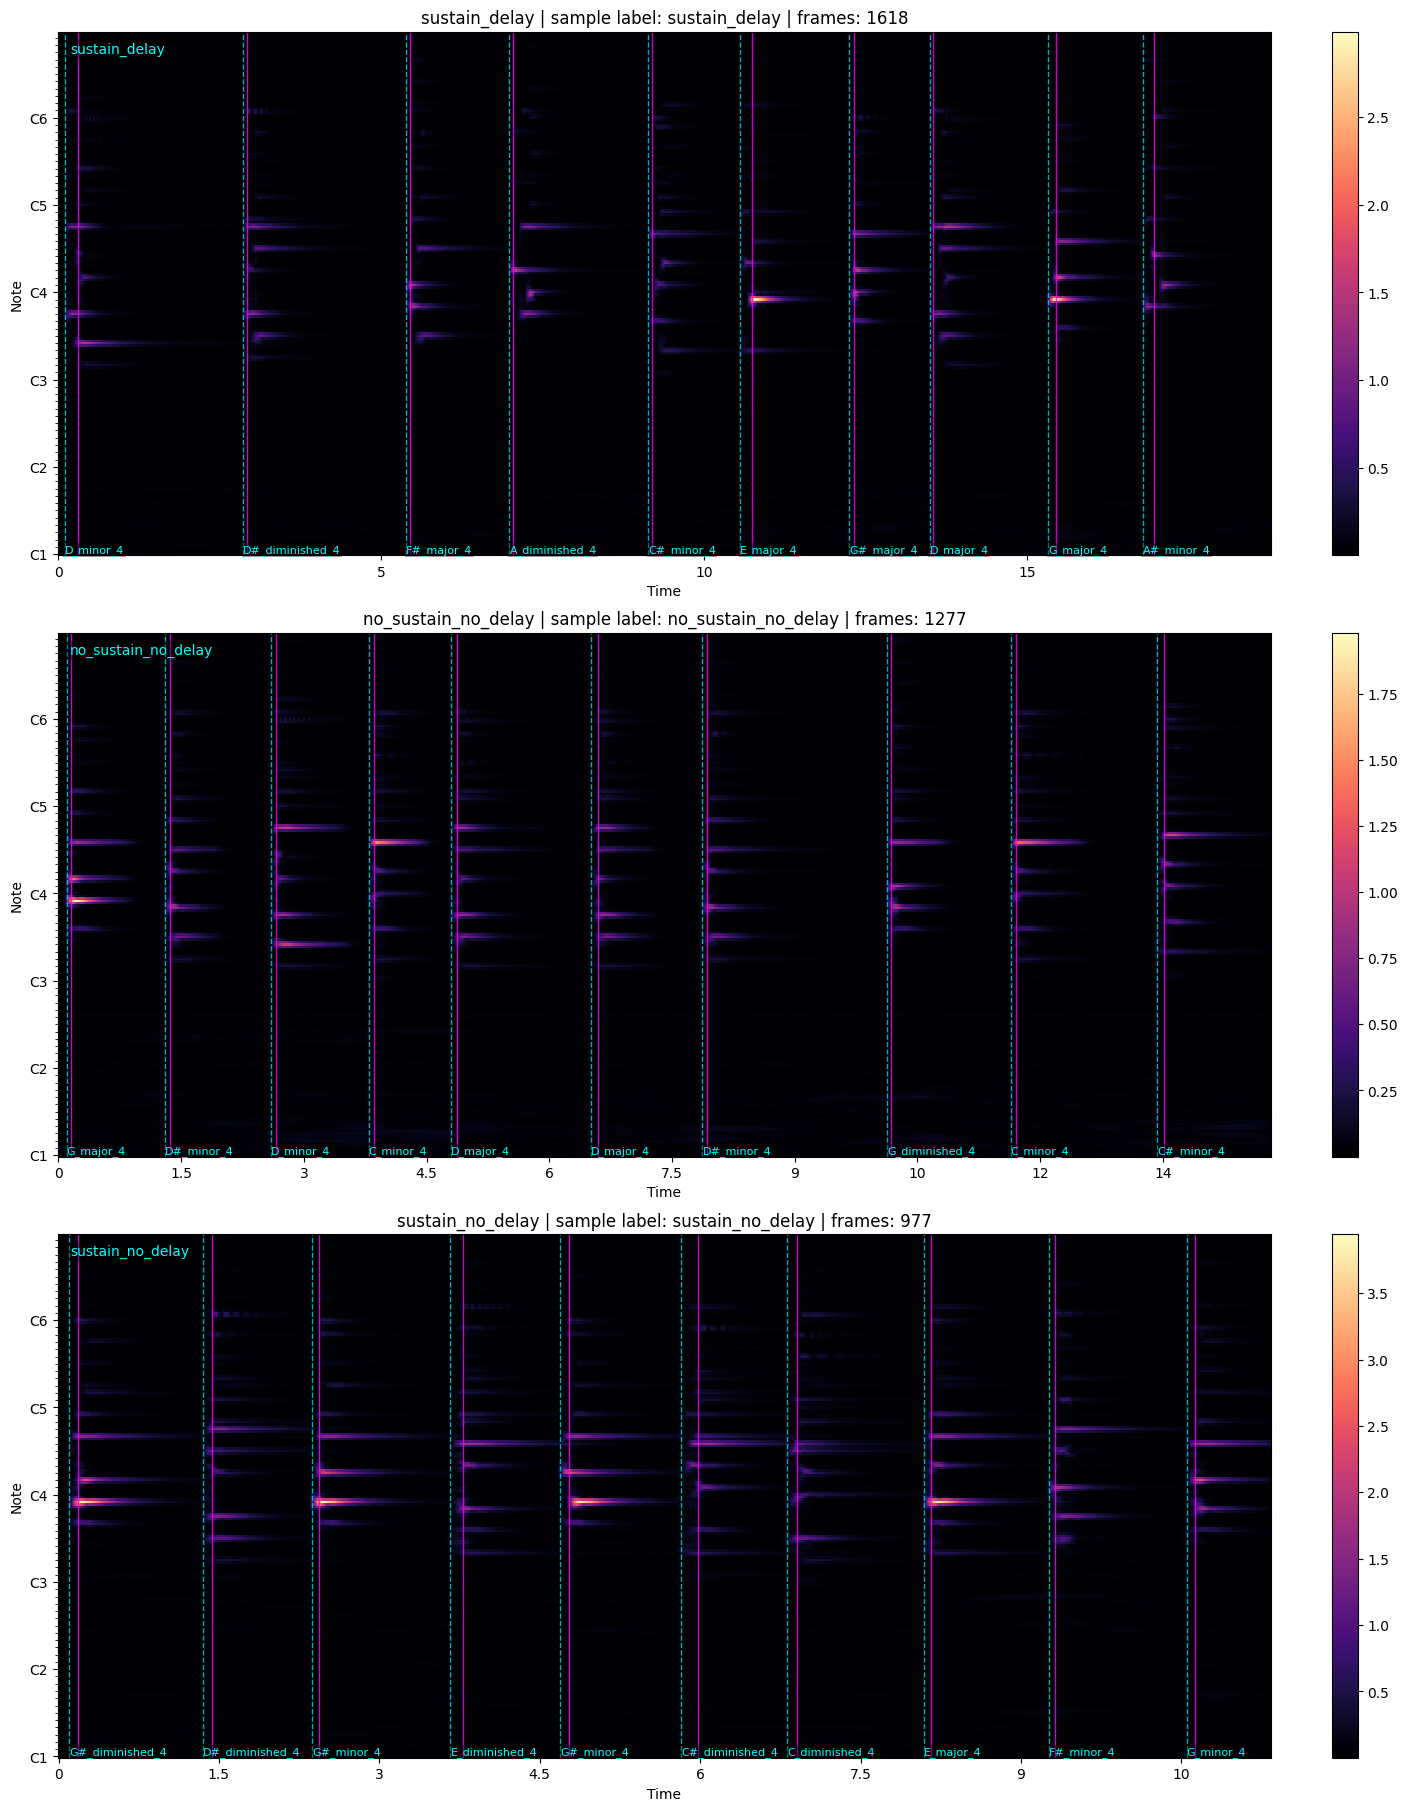

In [ ]:
bock_detections = detect_onsets_for_all_datasets(validation_datasets, PEAK_PICKING_BOCK)

fig, axes = plt.subplots(len(validation_datasets), 1, figsize=(14, 18), constrained_layout=True)

for axis, dataset_name in zip(axes, validation_datasets):
    dataset_result = bock_detections[dataset_name]
    sample_cqt = dataset_result["features"][0]
    annotations = dataset_result["annotations"][0]
    detected_onset_times = dataset_result["detections"][0]["onset_times"]

    image, _ = plot_feature_true_and_detected_onsets(
        sample_cqt,
        annotations,
        detected_onset_times=detected_onset_times,
        dataset_name=dataset_name,
        sample_label=dataset_result["labels"][0],
        ax=axis,
    )
    fig.colorbar(image, ax=axis)

plt.show()

## Comparison

In [43]:
import numpy as np
import pandas as pd
import mir_eval.onset
from IPython.display import display

def evaluate_onset_bundle(detection_bundle, method_name):
    rows = []
    for dataset_name, dataset_result in detection_bundle.items():
        for sample_index, detection in enumerate(dataset_result["detections"]):
            reference_onsets = np.asarray([annotation["start"] for annotation in detection["annotation"]], dtype=float)
            estimated_onsets = np.asarray(detection["onset_times"], dtype=float)
            scores = mir_eval.onset.evaluate(np.sort(reference_onsets), np.sort(estimated_onsets))

            rows.append({
                "method": method_name,
                "dataset": dataset_name,
                "sample_index": sample_index,
                "num_reference_onsets": int(reference_onsets.size),
                "num_estimated_onsets": int(estimated_onsets.size),
                **scores,
            })

    return pd.DataFrame(rows)

mcfee_results_df = evaluate_onset_bundle(mcfee_detections, "(McFee et al.)")
bock_results_df = evaluate_onset_bundle(bock_detections, "(Bock & Widmer)")
all_results_df = pd.concat([mcfee_results_df, bock_results_df], ignore_index=True)

identifier_columns = ["method", "dataset", "sample_index"]
metric_columns = [column for column in all_results_df.columns if column not in identifier_columns + ["num_reference_onsets", "num_estimated_onsets"]]

sample_results_df = all_results_df.sort_values(["dataset", "sample_index", "method"])
display(sample_results_df)

sample_comparison_df = mcfee_results_df.merge(
    bock_results_df,
    on=["dataset", "sample_index"],
    suffixes=("_mcfee", "_bock"),
)

for column in metric_columns:
    mcfee_column = f"{column}_mcfee"
    bock_column = f"{column}_bock"
    if mcfee_column in sample_comparison_df.columns and bock_column in sample_comparison_df.columns:
        sample_comparison_df[f"{column}_delta"] = sample_comparison_df[bock_column] - sample_comparison_df[mcfee_column]

summary_df = (
    all_results_df
    .groupby(["dataset", "method"], as_index=False)[metric_columns + ["num_reference_onsets", "num_estimated_onsets"]]
    .mean(numeric_only=True)
    .sort_values(["dataset", "method"])
)
display(summary_df)

comparison_df = summary_df.pivot(index="dataset", columns="method")
comparison_df.columns = [f"{metric} | {method}" for metric, method in comparison_df.columns]
for column in metric_columns:
    mcfee_column = f"{column} (McFee et al.)"
    bock_column = f"{column} (Bock & Widmer)"
    if mcfee_column in comparison_df.columns and bock_column in comparison_df.columns:
        comparison_df[f"{column} | delta (bock - mcfee)"] = comparison_df[bock_column] - comparison_df[mcfee_column]

display(comparison_df.reset_index())

overall_summary_df = (
    all_results_df
    .groupby("method", as_index=False)[metric_columns + ["num_reference_onsets", "num_estimated_onsets"]]
    .mean(numeric_only=True)
    .sort_values("method")
)
display(overall_summary_df)

,method,dataset,sample_index,num_reference_onsets,num_estimated_onsets,F-measure,Precision,Recall
82,(Bock & Widmer),no_sustain_no_delay,0,10,10,0.1,0.1,0.1
20,(McFee et al.),no_sustain_no_delay,0,10,10,1.0,1.0,1.0
83,(Bock & Widmer),no_sustain_no_delay,1,10,10,0.3,0.3,0.3
21,(McFee et al.),no_sustain_no_delay,1,10,10,1.0,1.0,1.0
84,(Bock & Widmer),no_sustain_no_delay,2,10,10,0.4,0.4,0.4
...,...,...,...,...,...,...,...,...
59,(McFee et al.),sustain_no_delay,7,10,10,1.0,1.0,1.0
122,(Bock & Widmer),sustain_no_delay,8,10,10,0.0,0.0,0.0
60,(McFee et al.),sustain_no_delay,8,10,10,1.0,1.0,1.0
123,(Bock & Widmer),sustain_no_delay,9,10,10,0.0,0.0,0.0


,dataset,method,F-measure,Precision,Recall,num_reference_onsets,num_estimated_onsets
0,no_sustain_no_delay,(Bock & Widmer),0.10625,0.10625,0.10625,10.0,10.0
1,no_sustain_no_delay,(McFee et al.),1.00000,1.00000,1.00000,10.0,10.0
2,sustain_delay,(Bock & Widmer),0.12500,0.12500,0.12500,10.0,10.0
3,sustain_delay,(McFee et al.),0.99000,0.99000,0.99000,10.0,10.0
4,sustain_no_delay,(Bock & Widmer),0.06000,0.06000,0.06000,10.0,10.0
5,sustain_no_delay,(McFee et al.),1.00000,1.00000,1.00000,10.0,10.0


,dataset,F-measure | (Bock & Widmer),F-measure | (McFee et al.),Precision | (Bock & Widmer),Precision | (McFee et al.),Recall | (Bock & Widmer),Recall | (McFee et al.),num_reference_onsets | (Bock & Widmer),num_reference_onsets | (McFee et al.),num_estimated_onsets | (Bock & Widmer),num_estimated_onsets | (McFee et al.)
0,no_sustain_no_delay,0.10625,1.00,0.10625,1.00,0.10625,1.00,10.0,10.0,10.0,10.0
1,sustain_delay,0.12500,0.99,0.12500,0.99,0.12500,0.99,10.0,10.0,10.0,10.0
2,sustain_no_delay,0.06000,1.00,0.06000,1.00,0.06000,1.00,10.0,10.0,10.0,10.0


,method,F-measure,Precision,Recall,num_reference_onsets,num_estimated_onsets
0,(Bock & Widmer),0.104839,0.104839,0.104839,10.0,10.0
1,(McFee et al.),0.996774,0.996774,0.996774,10.0,10.0


https://librosa.org/doc/latest/generated/librosa.onset.onset_detect.html

In this notebook both parameter sets are just different peak-picking configurations for the same offline pipeline, not two different detection modes. The gap is coming from the peak picker, not from `mir_eval`.

The main reason Bock does worse is that its peak-picking window is much more conservative. The McFee setting uses `post_max=1` and `post_avg=100`, while the Bock setting uses `post_max=30` and `post_avg=70`. In `librosa.util.peak_pick`, a candidate onset must be the maximum in its neighborhood and also be above the local mean by `delta`. With `post_max=30`, the decision depends on a much wider future window, so valid CQT onset peaks get merged away or suppressed much more often. That usually hurts recall first, which is exactly what your tables show in onset-detection.ipynb.

The other issue is mismatch. Those Bock-style parameters were tuned for a specific onset-detection setup in the literature, not for your CQT-based onset envelope. Here the envelope is computed from pre-extracted CQT features in onset-detection.ipynb, and the same settings are then applied across all validation datasets. McFee’s tighter `post_max=1` is simply better aligned with the sharper peaks produced by this representation, so it matches the ground-truth onsets much more closely.

In short: Bock is worse because its neighborhood constraints are too broad for these CQT onset envelopes, so it misses many true onsets. McFee is more sensitive and matches this data better.